<a href="https://colab.research.google.com/github/yooongZa/AIFFEL_Quest_EPA/blob/main/0903_WEAT_Movie_Genre_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 프로젝트 : 모든 장르 간 편향성 측정해 보기

### Colab 패키지 준비



In [ ]:
!apt-get update -qq
!apt-get install -qq openjdk-17-jdk fonts-nanum
%pip install -q gdown konlpy gensim scikit-learn seaborn


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libatspi2.0-0:amd64.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../00-libatspi2.0-0_2.44.0-3_amd64.deb ...
Unpacking libatspi2.0-0:amd64 (2.44.0-3) ...
Selecting previously unselected package libxtst6:amd64.
Preparing to unpack .../01-libxtst6_2%3a1.2.3-1build4_amd64.deb ...
Unpacking libxtst6:amd64 (2:1.2.3-1build4) ...
Selecting previously unselected package session-migration.
Preparing to unpack .../02-session-migration_0.3.6_amd64.deb ...
Unpacking session-migration (0.3.6) ...
Selecting previously unselected package gsettings-desktop-schemas.
Preparing to unpack .../03-gsettings-desktop-schemas_42.0-1ubuntu1_all.deb ...
Unpacking gsettings-desktop-schemas (42.0-1ubuntu1) ...
Selecting previously unselected

In [ ]:
import konlpy
import gensim
import sklearn
import seaborn

print(konlpy.__version__)
print(gensim.__version__)
print(sklearn.__version__)
print(seaborn.__version__)


0.6.0
4.4.0
1.6.1
0.13.2


### 데이터 준비



In [ ]:
from google.colab import drive
from pathlib import Path
import gdown
import zipfile

# Google Drive mount(마운트)
drive.mount("/content/drive")

# 모든 파일을 Google Drive에 영구 저장
data_dir = Path("/content/drive/MyDrive/Aiffel_EPA/weat/data")
data_dir.mkdir(parents=True, exist_ok=True)

zip_path = data_dir / "synopsis.zip"
file_id = "1MZPosOySFTA6dzwtdonqE11xz5vFL73F"

# ZIP이 없을 때만 Google Drive 공유 파일을 다운로드한다.
if not zip_path.exists():
    downloaded_path = gdown.download(
        id=file_id,
        output=str(zip_path),
        quiet=False,
    )
    if downloaded_path is None:
        raise RuntimeError("synopsis.zip 다운로드에 실패했습니다.")
else:
    print("기존 synopsis.zip을 사용합니다.")

if not zipfile.is_zipfile(zip_path):
    raise RuntimeError(f"올바른 ZIP 파일이 아닙니다: {zip_path}")

# 이미 압축을 푼 데이터가 없을 때만 압축을 푼다.
matches = list(data_dir.rglob("synopsis.txt"))
if not matches:
    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(data_dir)
    matches = list(data_dir.rglob("synopsis.txt"))

if len(matches) != 1:
    raise FileNotFoundError(
        f"synopsis.txt를 하나로 특정할 수 없습니다: {matches}"
    )

file_name = matches[0]
data_dir = file_name.parent

print(f"압축파일: {zip_path}")
print(f"데이터폴더: {data_dir}")
print(f"데이터파일: {file_name}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
기존 synopsis.zip을 사용합니다.
압축파일: /content/drive/MyDrive/Aiffel_EPA/weat/data/synopsis.zip
데이터폴더: /content/drive/MyDrive/Aiffel_EPA/weat/data
데이터파일: /content/drive/MyDrive/Aiffel_EPA/weat/data/synopsis.txt


In [ ]:
# 앞부분 20줄 확인
with file_name.open("r", encoding="utf-8") as file:
    for _ in range(20):
        line = file.readline()
        if not line:
            break
        print(line, end="")


사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와
 젊은 시절 상처한 한 아버지(박인환 분), 고모(신신애 분)와 함께 살고 있다.
 어느 겨울 그는 지방 방송국 라디오 PD 은수(이영애 분)를 만난다.
 자연의 소리를 채집해 틀어주는 라디오 프로그램을 준비하는 은수는 상우와 녹음 여행을 떠난다.
 자연스레 가까워지는 두 사람은 어느 날, 은수의 아파트에서 밤을 보낸다.
 너무 쉽게 사랑에 빠진 두 사람... 상우는 주체할 수 없을 정도로 그녀에게 빨려든다.
 그러나 겨울에 만난 두 사람의 관계는 봄을 지나 여름을 맞이하면서 삐걱거린다.
 이혼 경험이 있는 은수는 상우에게 결혼할 생각이 없다며 부담스러운 표정을 내비친다.
 "어떻게 사랑이 변하니?..."라고 묻는 상우에게 은수는 그저 "헤어져" 라고 단호하게 말한다.
 영원히 변할 것 같지 않던 사랑이 변하고, 그 사실을 받아들이지 못하는 상우는 어찌 할 바를 모른다.
 은수를 잊지 못하는 상우는 미련과 집착의 감정을 이기지 못하고 서울과 강릉을 오간다.
유사 이래 연령, 성별, 빈부의 차이와 정치적인 입장을 불문하고 일거에 국민을 통합해 온 '애국심'이라는 성역에 일침을 가하는 다큐멘터리. 재작년 전국 민족민주 유가족협의회의 장기농성을 다룬 인상적인 다큐멘터리 <민들레>를 만들었던 독립영화집단 '빨간 눈사람'이 우리 사회 구석구석을 발빠르게 돌아다니며 애국심과 민족주의가 강요되는 현장을 발굴하여 카메라에 담았다. 박홍 서강대 명예총장, 이도형 '한국논단' 발행인, 축구해설자 신문선, 홍세화, 박노해 등 사회 각계의 '스타'들이 등장해 저마다의 확고한 신념을 성토한다. 감독 이경순과 최하동하는 이 작품을 위해 3년간 백여 명을 인터뷰했다고 한다. 2001 올해의 독립영화상 수상.
 민족과 국가란 공동체에서 부단히 권력과 부를 얻는 자, 나아가 민족과 국가란 공동체에서 얻은 신분과 부귀를 영원히 그의 자손에게 대물림하려는 자, 그래서 민족과 국가란 공동체를 부단히 유지해야만 하는 자, 따라서

## STEP 1. 형태소 분석기를 이용하여 품사가 명사인 경우 해당 단어를 추출하기
---


예제와 같이 `Okt`로 형태소를 분석하고 명사만 `tokenized`에 담았다.

In [ ]:

from konlpy.tag import Okt

okt = Okt()
tokenized = []

with file_name.open("r", encoding="utf-8") as file:
    while True:
        line = file.readline()
        if not line:
            break
        words = okt.pos(line, stem=True, norm=True)
        res = []
        for w in words:
            if w[1] in ["Noun"]:  # 명사만 사용한다.
                res.append(w[0])   # 명사일 때만 tokenized 에 저장하게 됩니다.
        tokenized.append(res)

print("뿅~!")


뿅~!


In [ ]:
print("문장 수:", len(tokenized))
print("앞의 두 문장:", tokenized[:2])



문장 수: 71156
앞의 두 문장: [['사운드', '엔지니어', '상우', '유지태', '분', '치매', '할머니', '백성희', '분'], ['시절', '상처', '아버지', '박인환', '분', '고모', '신신애', '분', '살']]


## STEP 2. 추출된 결과로 embedding model 만들기
---

예제 코드를 참고해서 Word2Vec embedding model(임베딩 모델)을 학습한다. `most_similar()` 결과에서 비슷한 의미의 단어가 나오는지 직접 확인한다.

In [ ]:
from gensim.models import Word2Vec

# tokenized에 담긴 데이터를 가지고 나만의 Word2Vec을 생성합니다. (Gensim 4.0 기준)
model = Word2Vec(tokenized, vector_size=100, window=5, min_count=3, sg=0)
model.wv.most_similar(positive=['영화'])

# Gensim 3.X 에서는 아래와 같이 생성합니다.
# model = Word2Vec(tokenized, size=100, window=5, min_count=3, sg=0)
# model.most_similar(positive=['영화'])


[('작품', 0.8805237412452698),
 ('다큐멘터리', 0.837925374507904),
 ('드라마', 0.8237724900245667),
 ('영화로', 0.8077784776687622),
 ('코미디', 0.7925146222114563),
 ('형식', 0.7859868407249451),
 ('스토리', 0.7779133915901184),
 ('감동', 0.7724431753158569),
 ('주제', 0.7704707980155945),
 ('시대극', 0.7648661732673645)]

In [ ]:
model.wv.most_similar(positive=['사랑'])


[('토마슈', 0.7243435978889465),
 ('첫사랑', 0.7222849130630493),
 ('행복', 0.7071685791015625),
 ('진심', 0.7029886841773987),
 ('우정', 0.6906613707542419),
 ('애정', 0.6856626868247986),
 ('이별', 0.6841200590133667),
 ('시빌라', 0.6781306266784668),
 ('정일', 0.677563488483429),
 ('연애', 0.6770182251930237)]

In [ ]:
model.wv.most_similar(positive=['연극'])


[('영화감독', 0.8759056925773621),
 ('시나리오', 0.8740388751029968),
 ('영감', 0.8735038638114929),
 ('예술가', 0.8711630702018738),
 ('배우', 0.8574084043502808),
 ('예술', 0.8567590117454529),
 ('캐스팅', 0.8456491231918335),
 ('아티스트', 0.8442267775535583),
 ('대본', 0.8432957530021667),
 ('무용', 0.843124508857727)]

In [ ]:
assert model.wv.vector_size == 100
assert "영화" in model.wv

print("영화와 비슷한 단어:")
print(model.wv.most_similar(positive=["영화"], topn=5))


영화와 비슷한 단어:
[('작품', 0.8805237412452698), ('다큐멘터리', 0.837925374507904), ('드라마', 0.8237724900245667), ('영화로', 0.8077784776687622), ('코미디', 0.7925146222114563)]


## STEP 3. target, attribute 단어 셋 만들기
---

### 3-1. 예술영화와 일반영화 target 만들기 (중복 단어 제거)

먼저 예제와 동일하게 TF-IDF가 높은 단어를 정렬한다.  
두 목록에 함께 나온 단어와 Word2Vec에 없는 OOV(미등록어)는 제외한다.

In [ ]:
import os
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from konlpy.tag import Okt

art_txt = "synopsis_art.txt"
gen_txt = "synopsis_gen.txt"

def read_token(file_name):
    okt = Okt()
    result = []
    path = Path(data_dir) / file_name
    with path.open("r", encoding="utf-8") as fread:
        print(file_name, "파일을 읽고 있습니다.")
        while True:
            line = fread.readline()
            if not line:
                break
            tokenlist = okt.pos(line, stem=True, norm=True)
            for word in tokenlist:
                if word[1] in ["Noun"]:
                    result.append(word[0])
    return " ".join(result)

print("뿅뿅~!")


뿅뿅~!


In [ ]:
# 2개의 파일을 처리하는데 10분 가량 걸립니다.
art = read_token(art_txt)
gen = read_token(gen_txt)


synopsis_art.txt 파일을 읽고 있습니다.
synopsis_gen.txt 파일을 읽고 있습니다.


In [ ]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform([art, gen])

print(X.shape)


(2, 41082)


In [ ]:
# 앞 예제처럼 sparse matrix(희소 행렬)의 0이 아닌 값만 가져온다.
m1 = X[0].tocoo()
m2 = X[1].tocoo()

w1 = [[i, j] for i, j in zip(m1.col, m1.data)]
w2 = [[i, j] for i, j in zip(m2.col, m2.data)]

w1.sort(key=lambda x: x[1], reverse=True)
w2.sort(key=lambda x: x[1], reverse=True)

feature_names = vectorizer.get_feature_names_out()
preview_count = min(100, len(w1), len(w2))

print("예술영화를 대표하는 단어들:")
for i in range(preview_count):
    print(feature_names[w1[i][0]], end=", ")

print("\n")

print("일반영화를 대표하는 단어들:")
for i in range(preview_count):
    print(feature_names[w2[i][0]], end=", ")


예술영화를 대표하는 단어들:
그녀, 자신, 시작, 위해, 사랑, 사람, 영화, 친구, 남자, 가족, 이야기, 마을, 사건, 마음, 세상, 아버지, 아이, 엄마, 모든, 여자, 대한, 서로, 과연, 시간, 다시, 아들, 소녀, 아내, 다른, 영화제, 사이, 세계, 사실, 하나, 점점, 남편, 감독, 여행, 인생, 발견, 모두, 순간, 우리, 가장, 마지막, 아빠, 생활, 통해, 모습, 기억, 죽음, 비밀, 학교, 음악, 한편, 소년, 생각, 도시, 명의, 결혼, 사고, 전쟁, 위기, 때문, 이제, 최고, 이자, 과거, 일상, 경찰, 간다, 상황, 미국, 운명, 결심, 관계, 현실, 지금, 단편, 여인, 하루, 이름, 이후, 준비, 인간, 만난, 감정, 처음, 국제, 누구, 살인, 충격, 동안, 존재, 그린, 어머니, 연인, 계속, 동생, 작품, 

일반영화를 대표하는 단어들:
자신, 그녀, 영화제, 위해, 사람, 시작, 국제, 영화, 친구, 사랑, 남자, 이야기, 대한, 서울, 여자, 사건, 남편, 아이, 가족, 아버지, 다른, 마을, 시간, 엄마, 아들, 모든, 단편, 마음, 사실, 다시, 세계, 모습, 작품, 통해, 생각, 서로, 세상, 발견, 감독, 아내, 관계, 소녀, 사이, 하나, 우리, 애니메이션, 때문, 여성, 죽음, 과연, 점점, 인간, 생활, 한편, 결혼, 상황, 모두, 기억, 명의, 소년, 여행, 가장, 간다, 순간, 이제, 도시, 비밀, 학교, 과거, 가지, 이자, 경찰, 마지막, 미국, 동안, 전쟁, 주인공, 대해, 존재, 현실, 연출, 사고, 살인, 일상, 어머니, 계속, 사회, 인생, 다큐멘터리, 부문, 섹스, 최고, 바로, 의도, 동생, 하루, 위기, 계획, 정체, 한국, 

In [ ]:
# 앞 예제와 같이 상위 후보 중 서로 겹치지 않고 model에 있는 단어를 15개씩 선택한다.
n = 15
w1_ = [feature_names[w1[i][0]] for i in range(preview_count)]
w2_ = [feature_names[w2[i][0]] for i in range(preview_count)]

target_art = []
target_gen = []

for i in range(preview_count):
    if (w1_[i] not in w2_) and (w1_[i] in model.wv):
        target_art.append(w1_[i])
    if len(target_art) == n:
        break

for i in range(preview_count):
    if (w2_[i] not in w1_) and (w2_[i] in model.wv):
        target_gen.append(w2_[i])
    if len(target_gen) == n:
        break

if len(target_art) != n or len(target_gen) != n:
    raise RuntimeError(
        f"target 단어 수가 부족합니다: art={len(target_art)}, gen={len(target_gen)}"
    )


In [ ]:
print(target_art)


['아빠', '음악', '운명', '결심', '지금', '여인', '이름', '이후', '준비', '만난', '감정', '처음', '누구', '충격', '그린']


In [ ]:
print(target_gen)


['서울', '애니메이션', '여성', '가지', '주인공', '대해', '연출', '사회', '다큐멘터리', '부문', '섹스', '바로', '의도', '계획', '정체']


In [ ]:
assert len(target_art) == len(target_gen) == 15
assert set(target_art).isdisjoint(target_gen)
assert all(word in model.wv for word in target_art + target_gen)

print("target 단어 검증 완료")


target 단어 검증 완료


### 3-2. 21개 장르 attribute 만들기

다음 장르 목록은 과제에서 제공한 순서 그대로 사용한다. 6개 장르 예제의 `genre → TF-IDF → attributes` 흐름을 다시 실행한다.

In [ ]:
genre_txt = ['synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt', 'synopsis_etc.txt',
             'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
             'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt', 'synopsis_western.txt',
             'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt', 'synopsis_action.txt',
             'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt']
genre_name = ['SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마', '멜로로맨스', '뮤지컬', '미스터리', '범죄', '사극', '서부극(웨스턴)',
         '성인물(에로)', '스릴러', '애니메이션', '액션', '어드벤처', '전쟁', '코미디', '판타지']


In [ ]:
required_files = [art_txt, gen_txt, *genre_txt]
missing_files = [
    name for name in required_files
    if not (Path(data_dir) / name).is_file()
]

if missing_files:
    raise FileNotFoundError(f"누락된 데이터 파일: {missing_files}")

assert len(genre_txt) == len(genre_name) == 21
print("21개 장르 파일 확인 완료")


21개 장르 파일 확인 완료


In [ ]:
# 약 10분정도 걸립니다.
genre = []
for file_name in genre_txt:
    genre.append(read_token(file_name))


synopsis_SF.txt 파일을 읽고 있습니다.
synopsis_family.txt 파일을 읽고 있습니다.
synopsis_show.txt 파일을 읽고 있습니다.
synopsis_horror.txt 파일을 읽고 있습니다.
synopsis_etc.txt 파일을 읽고 있습니다.
synopsis_documentary.txt 파일을 읽고 있습니다.
synopsis_drama.txt 파일을 읽고 있습니다.
synopsis_romance.txt 파일을 읽고 있습니다.
synopsis_musical.txt 파일을 읽고 있습니다.
synopsis_mystery.txt 파일을 읽고 있습니다.
synopsis_crime.txt 파일을 읽고 있습니다.
synopsis_historical.txt 파일을 읽고 있습니다.
synopsis_western.txt 파일을 읽고 있습니다.
synopsis_adult.txt 파일을 읽고 있습니다.
synopsis_thriller.txt 파일을 읽고 있습니다.
synopsis_animation.txt 파일을 읽고 있습니다.
synopsis_action.txt 파일을 읽고 있습니다.
synopsis_adventure.txt 파일을 읽고 있습니다.
synopsis_war.txt 파일을 읽고 있습니다.
synopsis_comedy.txt 파일을 읽고 있습니다.
synopsis_fantasy.txt 파일을 읽고 있습니다.


In [ ]:
assert len(genre) == 21
assert all(len(document) > 0 for document in genre)

print("읽은 장르 수:", len(genre))


읽은 장르 수: 21


In [ ]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(genre)

print(X.shape)


(21, 42191)


#### 중복 단어를 줄인 방법

한 단어가 여러 장르에서 높게 나오면 중복될 수 있다.  

그래서 현재 장르의 TF-IDF 점수가 다른 모든 장르의 최고 점수를 초과할때만 선택한다. 하나의 단어는 하나의 장르의 atrr에만 포함될 수 있다.

target 단어와 OOV도 제외했다.

In [ ]:
m = [X[i].tocoo() for i in range(X.shape[0])]
w = [[[i, j] for i, j in zip(mm.col, mm.data)] for mm in m]

for i in range(len(w)):
    w[i].sort(key=lambda x: x[1], reverse=True)

feature_names = vectorizer.get_feature_names_out()
target_words = set(target_art + target_gen)
attributes = []

for i in range(len(w)):
    print(genre_name[i], end=": ")
    attr = []
    j = 0

    # j가 후보 수를 넘지 않도록 범위를 제한한다.
    while len(attr) < 15 and j < len(w[i]):
        word_index = w[i][j][0]
        word = feature_names[word_index]

        # 같은 단어의 21개 장르 TF-IDF 점수를 비교한다.
        genre_scores = X[:, word_index].toarray().ravel()
        other_scores = np.delete(genre_scores, i)
        # 현재 장르의 TF-IDF가 다른 모든 장르의 최고점보다 클 때만 선택한다.
        is_unique_best = genre_scores[i] > np.max(other_scores)

        if (
            word in model.wv
            and word not in target_words
            and is_unique_best
        ):
            attr.append(word)
            print(word, end=", ")

        j += 1

    if len(attr) != 15:
        raise RuntimeError(
            f"{genre_name[i]} 대표어가 {len(attr)}개만 선택되었습니다."
        )

    attributes.append(attr)
    print()


SF: 지구, 인류, 인간, 미래, 우주, 로봇, 모든, 박사, 우주선, 외계, 존재, 행성, 실험, 능력, 시스템, 
가족: 엄마, 가족, 아주르, 아버지, 아들, 낙타, 할머니, 씨제이, 동구, 학교, 소년, 슈이트, 어머니, 마갈, 미아, 
공연: 오페라, 토스카, 실황, 올레, 카바, 공연, 오텔로, 리골레토, 백작, 프레, 베르디, 비바, 카르피, 왕자, 콘서트, 
공포(호러): 시작, 사람, 친구, 공포, 발견, 죽음, 악령, 좀비, 하나, 저주, 명의, 일행, 시체, 계속, 악몽, 
기타: 영화제, 국제, 단편, 뉴미디어, 독립, 아시아나, 이미지, 부산, 상영작, 지하철, 청소년, 유럽, 포럼, 메트로, 실험영화, 
다큐멘터리: 영화, 다큐, 이야기, 대한, 감독, 우리, 세계, 통해, 한국, 작품, 환경, 모습, 노동자, 가장, 기록, 
드라마: 시간, 다른, 간다, 하루, 상처, 시절, 청년, 전주, 오늘, 소개, 드라마, 이해, 포기, 하루하루, 청춘, 
멜로로맨스: 그녀, 사랑, 남자, 여자, 마음, 결혼, 서로, 부부, 사이, 유혹, 연애, 애인, 새엄마, 남자친구, 선배, 
뮤지컬: 뮤지컬, 에스메랄다, 충무로, 모차르트, 니웨, 바흐, 프롤, 페뷔스, 모도, 샤오캉, 제루샤, 데이비, 팬텀, 크리스틴, 노트르담, 
미스터리: 사건, 사고, 진실, 기억, 민혁, 의문, 미스터리, 현우, 발생, 방독면, 소설, 추적, 의심, 조사, 사진, 
범죄: 경찰, 범죄, 마약, 형사, 살해, 수사, 한길수, 범인, 은행, 동료, 마피아, 용의자, 제안, 이자, 프랭크, 
사극: 조선, 신기전, 아가멤논, 황제, 루안, 최고, 하선, 윤서, 트로이, 히파티아, 신재효, 채선, 노준, 허균, 세자, 
서부극(웨스턴): 서부, 보안관, 벌린, 카우보이, 그레이프바인, 헨리, 마을, 개릿, 아이, 무법자, 프린트, 태구, 마적, 현상금, 분노, 
성인물(에로): 남편, 마사지, 관계, 정사, 유부녀, 에피소드, 다시, 자위, 회사, 불륜, 욕구, 때문,

In [ ]:
flat_attributes = [
    word
    for attribute in attributes
    for word in attribute
]

assert len(attributes) == 21
assert all(len(attribute) == 15 for attribute in attributes)
assert len(flat_attributes) == 21 * 15
assert len(flat_attributes) == len(set(flat_attributes))
assert target_words.isdisjoint(flat_attributes)
assert all(word in model.wv for word in flat_attributes)

print("attribute 단어 검증 완료: 21개 장르 × 15개, 중복 0개")


attribute 단어 검증 완료: 21개 장르 × 15개, 중복 0개


## STEP 4. WEAT score 계산과 시각화
---

### WEAT 함수

기존 s()와 weat_score()의 계산 흐름은 유지하고, 여러 단어를 입력해도 각 단어 벡터 사이의 코사인 유사도가 계산되도록 cos_sim()을 행렬 입력이 가능한 형태로 수정했다.

In [ ]:
from numpy import dot
from numpy.linalg import norm

def cos_sim(i, j):
    i = np.atleast_2d(i)
    j = np.atleast_2d(j)

    i_norm = norm(i, axis=1, keepdims=True)
    j_norm = norm(j, axis=1, keepdims=True)

    if np.any(i_norm == 0) or np.any(j_norm == 0):
        raise ValueError("크기가 0인 벡터는 cosine similarity를 계산할 수 없습니다.")

    return dot(i, j.T) / (i_norm * j_norm.T)

def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    mean_A = np.mean(c_a, axis=-1)
    mean_B = np.mean(c_b, axis=-1)
    return mean_A - mean_B

def weat_score(X, Y, A, B):
    s_X = s(X, A, B)
    s_Y = s(Y, A, B)

    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)
    std_dev = np.std(np.concatenate([s_X, s_Y], axis=0))

    if np.isclose(std_dev, 0):
        raise ValueError("WEAT score의 표준편차가 0입니다.")

    return (mean_X - mean_Y) / std_dev


In [ ]:
# 기존 예제의 matrix를 사용하되 미계산 칸은 0이 아닌 NaN으로 둔다.
matrix = np.full(
    (len(genre_name), len(genre_name)),
    np.nan,
)

X = np.array([model.wv[word] for word in target_art])
Y = np.array([model.wv[word] for word in target_gen])

pair_results = []

for i in range(len(genre_name) - 1):
    for j in range(i + 1, len(genre_name)):
        A = np.array([model.wv[word] for word in attributes[i]])
        B = np.array([model.wv[word] for word in attributes[j]])
        score = weat_score(X, Y, A, B)
        matrix[i][j] = score
        pair_results.append((genre_name[i], genre_name[j], score))

print("뾰로롱~")


뾰로롱~


In [ ]:
# 모든 장르쌍을 출력한다.
for genre_a, genre_b, score in pair_results:
    print(genre_a, genre_b, score)


SF 가족 -0.9051475
SF 공연 -0.2736298
SF 공포(호러) -0.9363687
SF 기타 0.3994058
SF 다큐멘터리 0.153082
SF 드라마 -0.6561694
SF 멜로로맨스 -0.81181455
SF 뮤지컬 -0.1753637
SF 미스터리 -0.6525626
SF 범죄 -0.41825628
SF 사극 -0.5508254
SF 서부극(웨스턴) -0.54412353
SF 성인물(에로) -0.55428356
SF 스릴러 -0.7517864
SF 애니메이션 -0.1599322
SF 액션 -0.4731175
SF 어드벤처 -0.9665922
SF 전쟁 -0.09243514
SF 코미디 -0.7558366
SF 판타지 -0.8698763
가족 공연 0.9508201
가족 공포(호러) 0.20942023
가족 기타 1.0656719
가족 다큐멘터리 0.9115383
가족 드라마 0.46961775
가족 멜로로맨스 -0.2926588
가족 뮤지컬 1.0647612
가족 미스터리 0.5206171
가족 범죄 0.5486766
가족 사극 0.9136397
가족 서부극(웨스턴) 1.0167794
가족 성인물(에로) 0.25279686
가족 스릴러 0.29289094
가족 애니메이션 1.0932199
가족 액션 0.5399872
가족 어드벤처 0.6352752
가족 전쟁 0.9088545
가족 코미디 0.30478418
가족 판타지 0.7237416
공연 공포(호러) -0.5140552
공연 기타 0.881793
공연 다큐멘터리 0.40154165
공연 드라마 -0.53719306
공연 멜로로맨스 -0.84537846
공연 뮤지컬 0.43232515
공연 미스터리 -0.2968221
공연 범죄 -0.16358566
공연 사극 -0.35474712
공연 서부극(웨스턴) -0.3027709
공연 성인물(에로) -0.5045968
공연 스릴러 -0.55527955
공연 애니메이션 0.31496304
공연 액션 -0.13080798
공연 어드벤처 -0.

In [ ]:
# 절댓값이 큰 장르쌍 10개를 따로 확인한다.
sorted_results = sorted(
    pair_results,
    key=lambda item: abs(item[2]),
    reverse=True,
)

print("WEAT 절댓값 상위 10개")
for genre_a, genre_b, score in sorted_results[:10]:
    print(f"{genre_a:12s} / {genre_b:12s}: {score:.4f}")


WEAT 절댓값 상위 10개
멜로로맨스        / 성인물(에로)     : 1.2653
가족           / 애니메이션       : 1.0932
가족           / 기타          : 1.0657
가족           / 뮤지컬         : 1.0648
뮤지컬          / 코미디         : -1.0613
기타           / 코미디         : -1.0487
기타           / 드라마         : -1.0250
애니메이션        / 코미디         : -1.0218
가족           / 서부극(웨스턴)    : 1.0168
공연           / 코미디         : -0.9991


### Heatmap 시각화

행이 장르 A, 열이 장르 B이다. 양수와 음수의 방향을 구분하기 위해 0을 색상의 중심으로 두고, 실제로 계산한 upper triangle(상삼각형)만 표시한다.

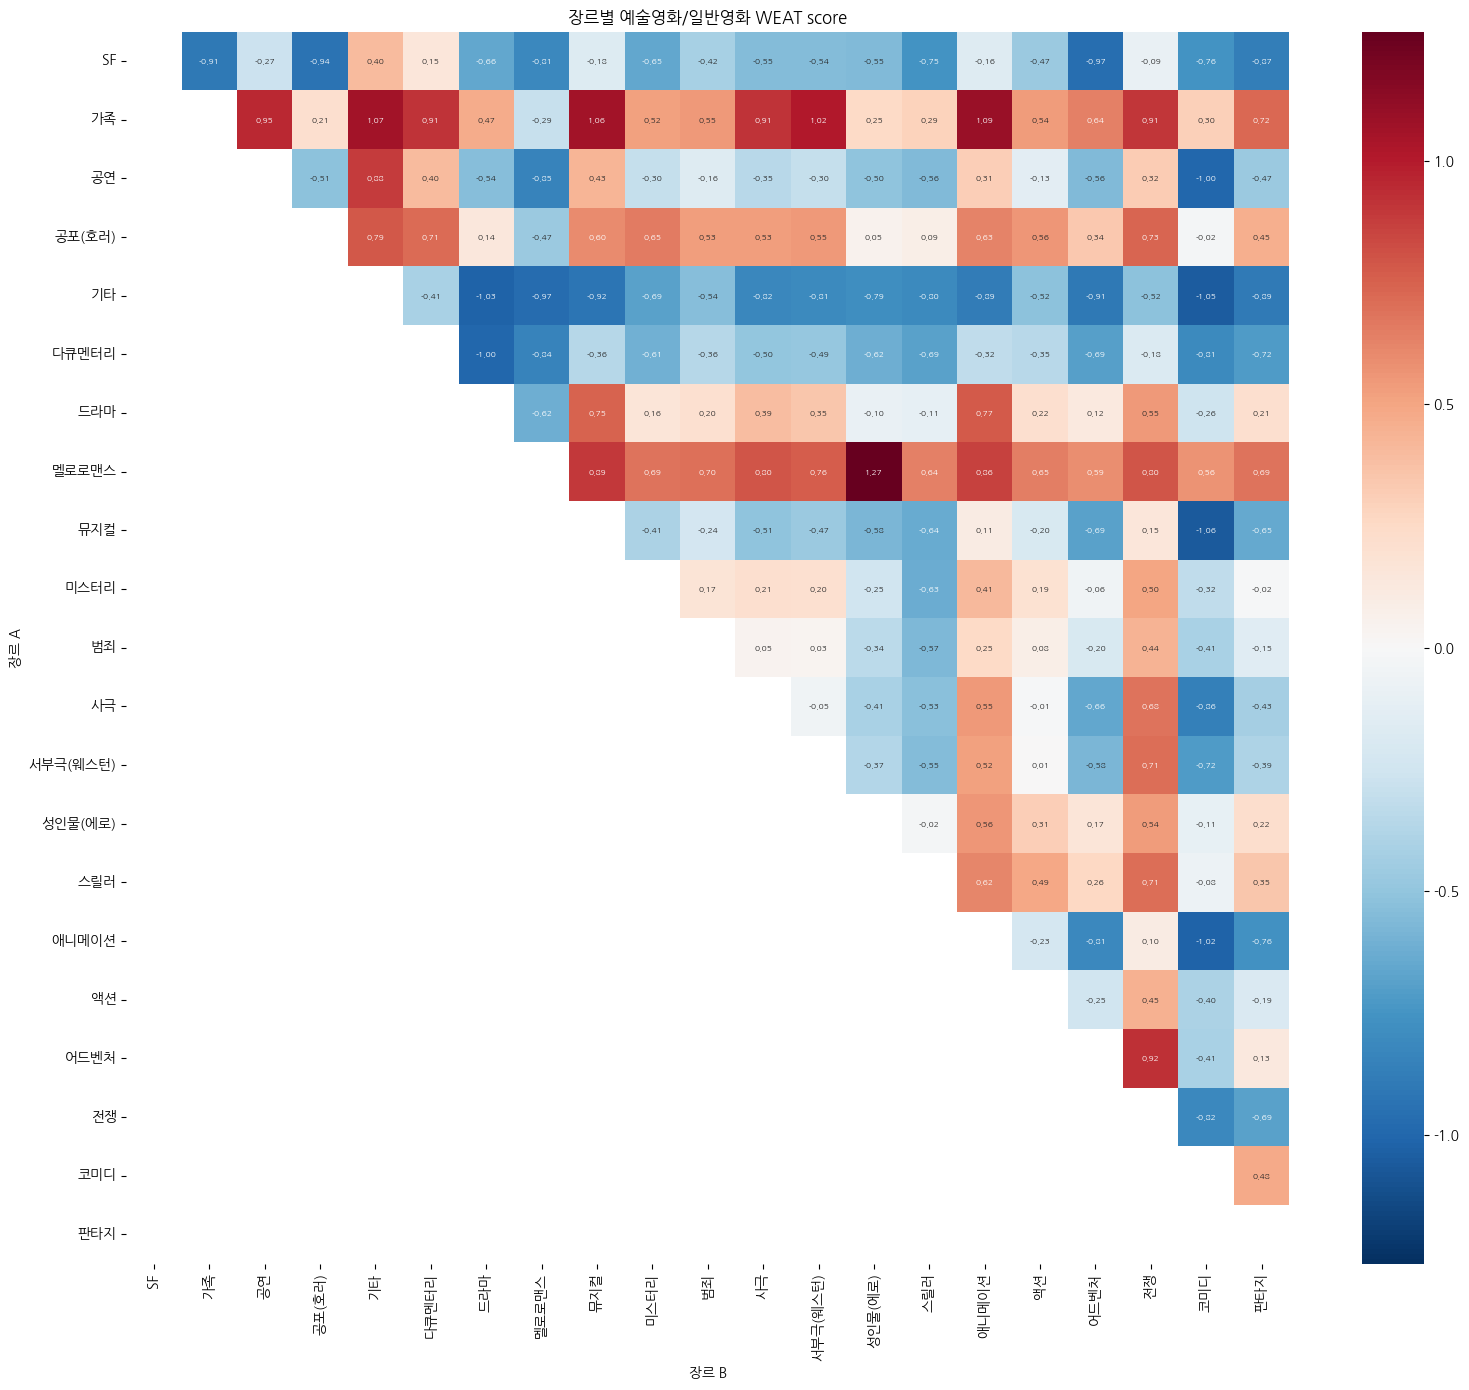

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if os.path.isfile(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc("font", family="NanumGothic")

plt.rcParams["axes.unicode_minus"] = False

limit = max(float(np.nanmax(np.abs(matrix))), 1e-12)
mask = np.isnan(matrix)

plt.figure(figsize=(16, 14))
ax = sns.heatmap(
    matrix,
    mask=mask,
    xticklabels=genre_name,
    yticklabels=genre_name,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    cmap="RdBu_r",
    center=0,
    vmin=-limit,
    vmax=limit,
)

ax.set_title("장르별 예술영화/일반영화 WEAT score")
ax.set_xlabel("장르 B")
ax.set_ylabel("장르 A")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 결과 해석 — 실행 결과를 보고 작성

기존 예제의 장르별 TF-IDF 정렬 방식은 유지했습니다.  

다만 같은 단어가 여러 장르의 대표 단어로 중복되는 문제를 줄이기 위해, 동일한 단어의 TF-IDF를 모든 장르에서 비교하고 점수가 가장 높은 장르에만 배정했습니다.  

이후 장르별 단어 수와 중복 여부를 검증했습니다.

## 시행착오와 회고

- `data_dir`가 `Path`인데 문자열 덧셈을 하면 오류가 생겨 `/`로 경로를 연결했다.
- 21개 장르 이름만 바꾸면 앞에서 만든 6개 `genre`와 `attributes`가 남기 때문에, 21개 목록 아래에서 전부 다시 계산했다.
- 중복되는 대표어는 한 장르에서 TF-IDF가 가장 높을 때만 선택하도록 조건을 추가했다.
- 미계산 영역을 0으로 두면 실제 0점처럼 보일 수 있어서 `NaN`으로 두었다.

### 실행 흐름

`시놉시스 → 명사 추출 → Word2Vec → TF-IDF 대표어 → 중복/OOV 제거 → 210개 WEAT → Heatmap`

### 배운 점

- 대표 단어를 어떻게 고르는지가 WEAT 결과에 큰 영향을 줄 수 있다는 점을 알게 되었다.
- 결과 숫자만 보는 것보다 실제 target/attribute 단어를 같이 확인하는 것이 중요했다.

### 아쉬운 점

- 실행 결과를 확인한 뒤 seed(시드)나 대표 단어 수를 바꿔도 비슷한 경향이 나오는지 추가로 실험해 보고 싶다.